In [1]:
import pandas as pd

crash=pd.read_csv('./data/deer_crash.csv')
vmt=pd.read_csv('./data/vehicle_miles.csv') #vehicle miles traveled

In [2]:
harvest = (
    pd.read_csv('./data/deer_harvest.csv')
    .drop(columns=['License Year','Antlered','Antlerless'])
    .rename(columns={'Total':'deer_harvest'})
    .rename(columns=str.lower)
)
harvest.head()

,county,deer_harvest
0,Alcona,4264
1,Alger,546
2,Allegan,6170
3,Alpena,4299
4,Antrim,2588


For NLCD land cover, combine categories into `habitat_pct`, `ag_pct`, and `developed_pct`

`habitat_pct`: NLCD 41 (Deciduous Forest), 42 (Evergreen Forest), 43 (Mixed Forest), 52 (Shrubland),  71 (Herbacrous), 90-95 (Wetlands)

`ag_pct`: 81(Pasure/Hay), 82(Cultivated Crops)

`developed_pct`: 21-24 (Open, low, med, high intensity developed)

In [3]:
land =(
    pd.read_csv('./data/land_cover_pct.csv')
    .assign(habitat_pct = lambda d: d['nlcd_41_pct']+d['nlcd_42_pct']+d['nlcd_43_pct']+d['nlcd_52_pct']+d['nlcd_71_pct']+d['nlcd_90_pct']+d['nlcd_95_pct'])
    .assign(ag_pct = lambda d: d['nlcd_81_pct'] + d['nlcd_82_pct'])
    .assign(developed_pct = lambda d: d['nlcd_21_pct'] + d['nlcd_22_pct']+ d['nlcd_23_pct']+d['nlcd_24_pct'])
)
land = land[['county','habitat_pct','ag_pct','developed_pct']]
land.head()

,county,habitat_pct,ag_pct,developed_pct
0,Alcona,0.832365,0.086674,0.049117
1,Alger,0.924761,0.023632,0.023837
2,Allegan,0.403888,0.431734,0.143876
3,Alpena,0.708595,0.177494,0.068969
4,Antrim,0.723022,0.096327,0.081020


In [6]:
counties = (
    pd.read_csv('./data/mi_county_info.csv')
    .assign(pop_density = lambda d: d['population']/d['area'])
)

counties = counties[['county','pop_density']]

In [7]:
counties.head()

,county,pop_density
0,Alcona,5.931882
1,Alger,1.722123
2,Allegan,66.791598
3,Alpena,17.051917
4,Antrim,40.757475


In [21]:
vmt = (
    pd.read_csv('./data/vehicle_miles.csv')
    .rename(columns=str.lower)
    # .drop(columns=['other','total'])
)
vmt = vmt[['county','total']].rename(columns={'total':'vmt'})

In [22]:
vmt.head()

,county,vmt
0,Alcona,132716
1,Alger,156839
2,Allegan,1666146
3,Alpena,298426
4,Antrim,320619


In [23]:
merge_column = 'county'

merge_column = 'county'

features = (
    vmt
    .merge(counties, on=merge_column, how='left')
    .merge(land, on=merge_column, how='left')
    .merge(harvest, on=merge_column, how='left')
    .merge(crash, on=merge_column, how='left')
)

features

,county,vmt,pop_density,habitat_pct,ag_pct,developed_pct,deer_harvest,crashes
0,Alcona,132716,5.931882,0.832365,0.086674,0.049117,4264,409
1,Alger,156839,1.722123,0.924761,0.023632,0.023837,546,107
2,Allegan,1666146,66.791598,0.403888,0.431734,0.143876,6170,1517
3,Alpena,298426,17.051917,0.708595,0.177494,0.068969,4299,266
4,Antrim,320619,40.757475,0.723022,0.096327,0.081020,2588,570
...,...,...,...,...,...,...,...,...
78,Tuscola,523586,57.721007,0.279850,0.620823,0.093672,7136,1189
79,Van Buren,1136446,69.843119,0.428788,0.419623,0.133343,3743,944
80,Washtenaw,3803358,517.116183,0.318791,0.400520,0.258971,5070,1409
81,Wayne,14744620,2635.510417,0.121914,0.042509,0.824345,525,624


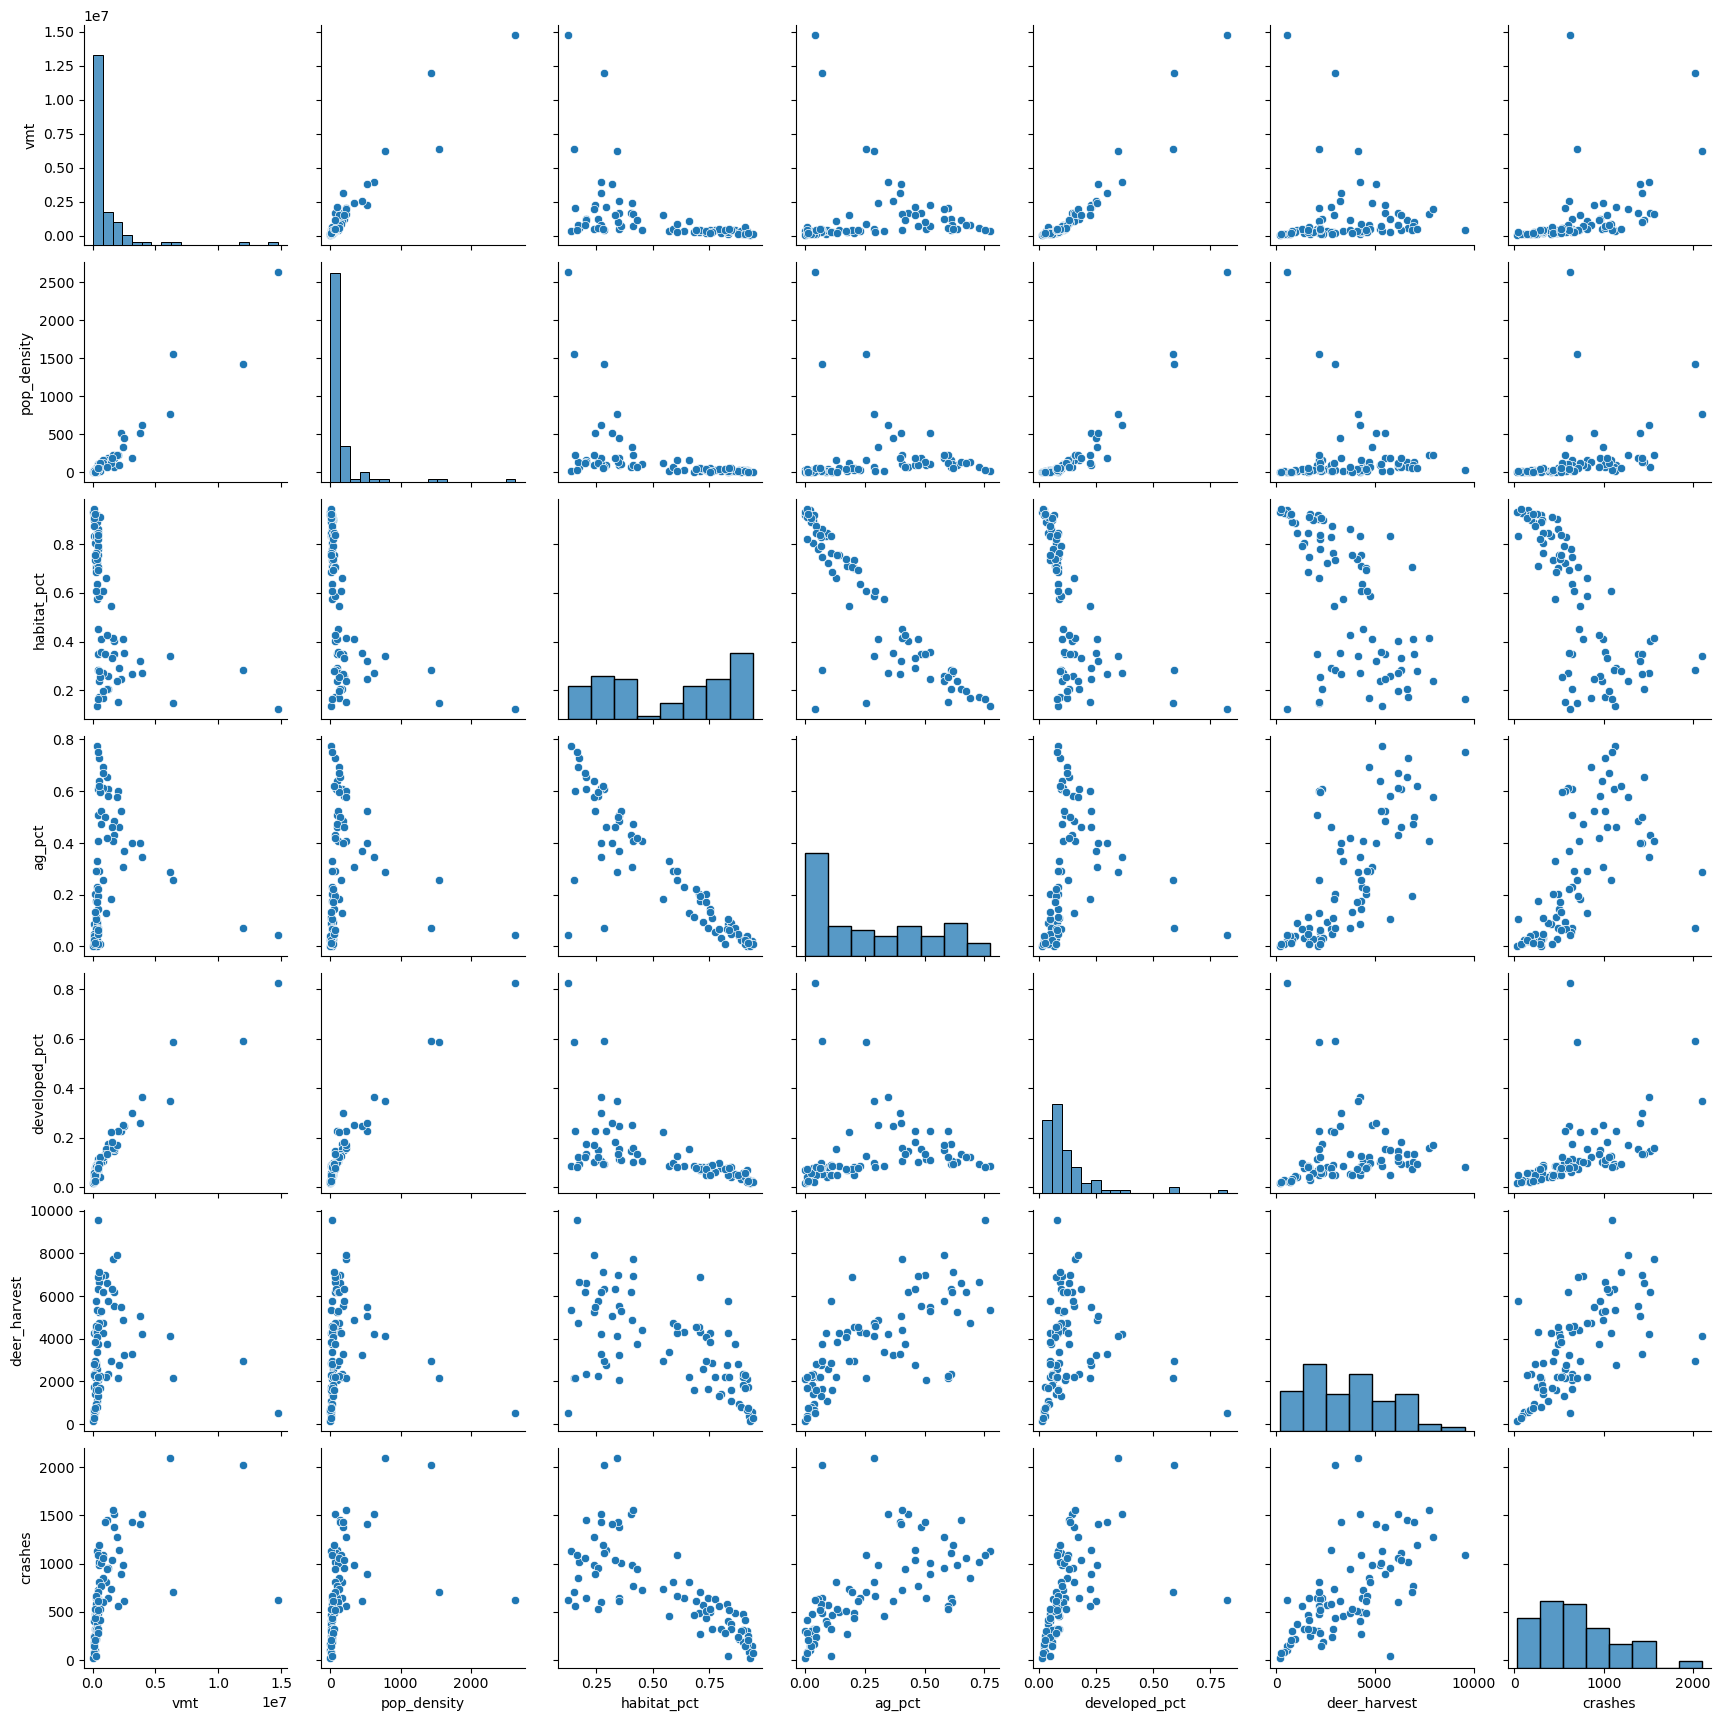

In [24]:
import seaborn as sns

X = features
sns.pairplot(X)